In [45]:
!pip install kagglehub lightgbm


In [46]:
# SETUP, IMPORTS & DATA DOWNLOAD

import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
import random
import time
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("   LightGBM-based IoT Intrusion Detection System")
print("   Dataset: CICIoT2023")
print("=" * 60)
print("\n=== Downloading Dataset via Kagglehub ===")
path = kagglehub.dataset_download("himadri07/ciciot2023")
print(f"Path to dataset files: {path}")
print(f"Files available: {os.listdir(path)}")

   LightGBM-based IoT Intrusion Detection System
   Dataset: CICIoT2023

=== Downloading Dataset via Kagglehub ===
Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\himadri07\ciciot2023\versions\1
Files available: ['CICIOT23']


In [47]:
#LOAD TRAIN, VALIDATION, AND TEST DATA

print("=== Loading Datasets ===")


train_path, val_path, test_path = None, None, None

for root, dirs, files in os.walk(path):
    for file in files:
        if 'train' in file.lower() and file.endswith('.csv'):
            train_path = os.path.join(root, file)
        elif 'val' in file.lower() and file.endswith('.csv'):
            val_path = os.path.join(root, file)
        elif 'test' in file.lower() and file.endswith('.csv'):
            test_path = os.path.join(root, file)

print(f"Found Train file at: {train_path}")
print(f"Found Val file at:   {val_path}")
print(f"Found Test file at:  {test_path}\n")

if not all([train_path, val_path, test_path]):
    print(" ERROR: Could not find all CSV files! Check the dataset folder.")
else:
    print("Loading Data...")

    df_train = pd.read_csv(train_path, nrows=1000000)
    df_val = pd.read_csv(val_path, nrows=200000)
    df_test = pd.read_csv(test_path, nrows=300000)

    print(f"\nTrain shape:      {df_train.shape}  ({df_train.shape[0]:,} rows × {df_train.shape[1]} columns)")
    print(f"Validation shape: {df_val.shape}  ({df_val.shape[0]:,} rows × {df_val.shape[1]} columns)")
    print(f"Test shape:       {df_test.shape}  ({df_test.shape[0]:,} rows × {df_test.shape[1]} columns)")
    print(f"\nTotal samples loaded: {df_train.shape[0] + df_val.shape[0] + df_test.shape[0]:,}")

=== Loading Datasets ===
Found Train file at: C:\Users\USER\.cache\kagglehub\datasets\himadri07\ciciot2023\versions\1\CICIOT23\train\train.csv
Found Val file at:   C:\Users\USER\.cache\kagglehub\datasets\himadri07\ciciot2023\versions\1\CICIOT23\validation\validation.csv
Found Test file at:  C:\Users\USER\.cache\kagglehub\datasets\himadri07\ciciot2023\versions\1\CICIOT23\test\test.csv

Loading Data...

Train shape:      (1000000, 47)  (1,000,000 rows × 47 columns)
Validation shape: (200000, 47)  (200,000 rows × 47 columns)
Test shape:       (300000, 47)  (300,000 rows × 47 columns)

Total samples loaded: 1,500,000


In [48]:

# EXPLORATORY DATA ANALYSIS

print("=== Exploratory Data Analysis ===")

print("\n--- 3.1 Dataset Information ---")
print(f"Total Features: {df_train.shape[1] - 1} (excluding target label)")
print(f"Target Column: 'label'")
print(f"\nColumn Names:")
for i, col in enumerate(df_train.columns, 1):
    print(f"  {i:2d}. {col}", end="\t")
    if i % 4 == 0:
        print()
print()
print("\n--- 3.2 Feature Data Types ---")
print(f"Numeric features (float64): {df_train.select_dtypes(include='float64').shape[1]}")
print(f"Categorical features (object): {df_train.select_dtypes(include='object').shape[1]}")
print("\n--- 3.3 Statistical Summary (First 5 rows) ---")
display(df_train.head())

=== Exploratory Data Analysis ===

--- 3.1 Dataset Information ---
Total Features: 46 (excluding target label)
Target Column: 'label'

Column Names:
   1. flow_duration	   2. Header_Length	   3. Protocol Type	   4. Duration	
   5. Rate	   6. Srate	   7. Drate	   8. fin_flag_number	
   9. syn_flag_number	  10. rst_flag_number	  11. psh_flag_number	  12. ack_flag_number	
  13. ece_flag_number	  14. cwr_flag_number	  15. ack_count	  16. syn_count	
  17. fin_count	  18. urg_count	  19. rst_count	  20. HTTP	
  21. HTTPS	  22. DNS	  23. Telnet	  24. SMTP	
  25. SSH	  26. IRC	  27. TCP	  28. UDP	
  29. DHCP	  30. ARP	  31. ICMP	  32. IPv	
  33. LLC	  34. Tot sum	  35. Min	  36. Max	
  37. AVG	  38. Std	  39. Tot size	  40. IAT	
  41. Number	  42. Magnitue	  43. Radius	  44. Covariance	
  45. Variance	  46. Weight	  47. label	

--- 3.2 Feature Data Types ---
Numeric features (float64): 46
Categorical features (object): 1

--- 3.3 Statistical Summary (First 5 rows) ---


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,757.00,6.00,64.00,23.671858,23.671858,0.0,0.0,0.0,0.0,...,538.470740,944.00,8.334058e+07,9.5,41.845546,761.456760,305219.322301,0.95,141.55,DDoS-ACK_Fragmentation
1,0.000000,54.00,6.00,64.00,2.393046,2.393046,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.309327e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
2,0.033982,56.78,6.11,64.64,1.192715,1.192715,0.0,0.0,0.0,0.0,...,1.727526,54.29,8.333086e+07,9.5,10.462813,2.445286,16.853118,0.19,141.55,DDoS-PSHACK_Flood
3,0.000000,0.00,47.00,64.00,9.841972,9.841972,0.0,0.0,0.0,0.0,...,0.000000,592.00,8.370278e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
4,3.944828,108.00,6.00,64.00,0.506993,0.506993,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.297270e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood


=== Class Distribution Analysis ===

Total unique classes: 34
Most common class:   DDoS-ICMP_Flood (154,708 samples)
Least common class:  Uploading_Attack (31 samples)
Imbalance ratio:     4990.6x

--- Full Class Distribution ---
   1. DDoS-ICMP_Flood                      154,708  (15.47%) 
   2. DDoS-UDP_Flood                       115,860  (11.59%) 
   3. DDoS-TCP_Flood                        96,361  ( 9.64%) 
   4. DDoS-SYN_Flood                        87,578  ( 8.76%) 
   5. DDoS-PSHACK_Flood                     87,563  ( 8.76%) 
   6. DDoS-RSTFINFlood                      86,461  ( 8.65%) 
   7. DDoS-SynonymousIP_Flood               77,082  ( 7.71%) 
   8. DoS-UDP_Flood                         71,180  ( 7.12%) 
   9. DoS-TCP_Flood                         57,061  ( 5.71%) 
  10. DoS-SYN_Flood                         43,046  ( 4.30%) 
  11. BenignTraffic                         23,455  ( 2.35%) 
  12. Mirai-greeth_flood                    21,207  ( 2.12%) 
  13. Mirai-udpplain      

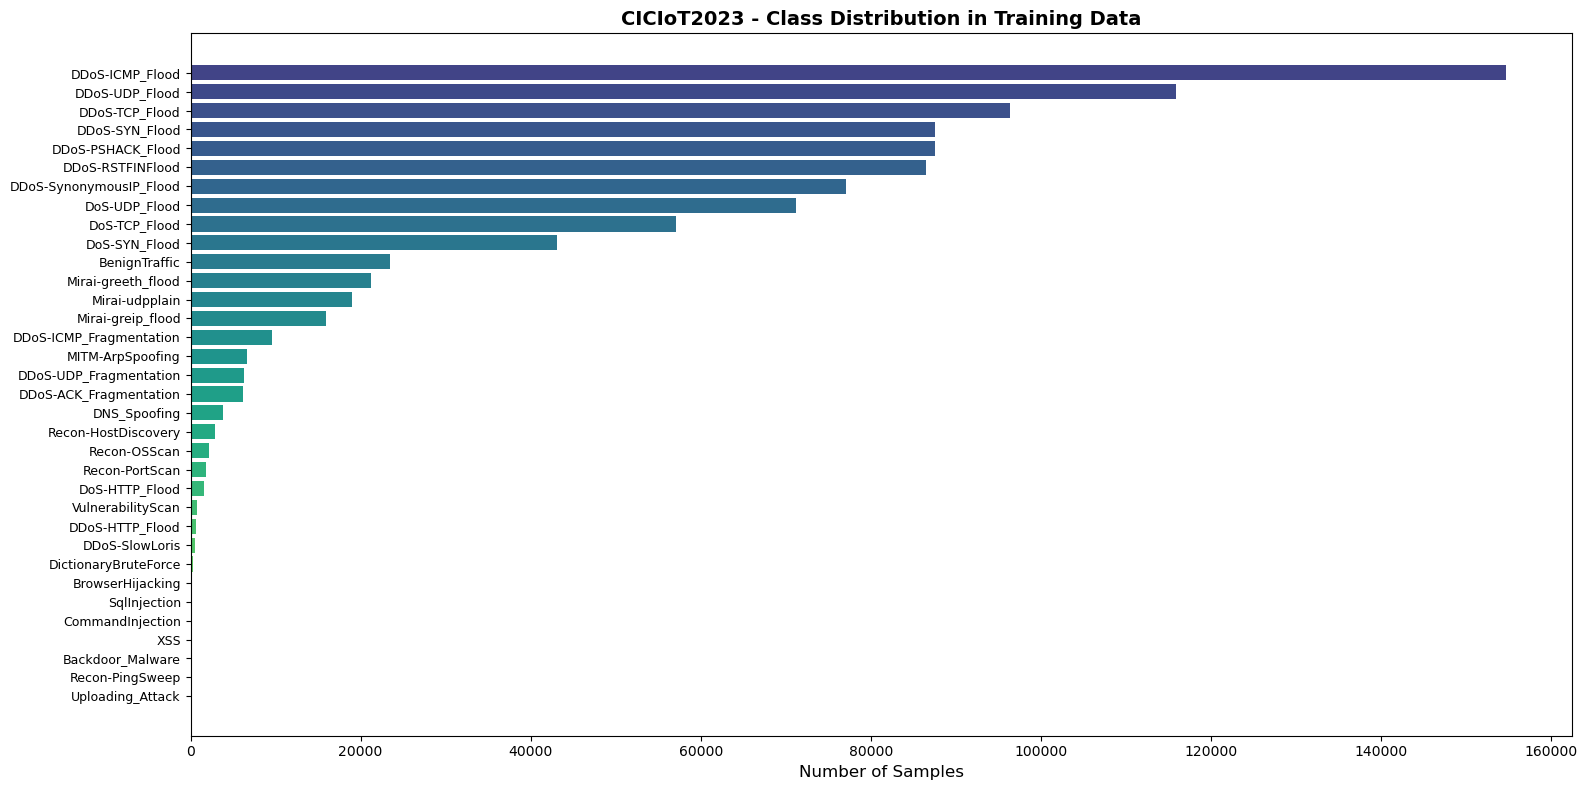


 Observation: The dataset is HIGHLY IMBALANCED.
   LightGBM's 'is_unbalance' parameter will be used to address this.


In [49]:

# CLASS DISTRIBUTION ANALYSIS

print("=== Class Distribution Analysis ===")

class_dist = df_train['label'].value_counts()
print(f"\nTotal unique classes: {len(class_dist)}")
print(f"Most common class:   {class_dist.index[0]} ({class_dist.iloc[0]:,} samples)")
print(f"Least common class:  {class_dist.index[-1]} ({class_dist.iloc[-1]:,} samples)")
print(f"Imbalance ratio:     {class_dist.iloc[0] / class_dist.iloc[-1]:.1f}x\n")
print("--- Full Class Distribution ---")
for i, (label, count) in enumerate(class_dist.items(), 1):
    pct = count / len(df_train) * 100
    bar = '' * int(pct * 2)
    print(f"  {i:2d}. {label:35s} {count:>8,}  ({pct:5.2f}%) {bar}")
plt.figure(figsize=(16, 8))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(class_dist)))
bars = plt.barh(range(len(class_dist)), class_dist.values, color=colors)
plt.yticks(range(len(class_dist)), class_dist.index, fontsize=9)
plt.xlabel('Number of Samples', fontsize=12)
plt.title('CICIoT2023 - Class Distribution in Training Data', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n Observation: The dataset is HIGHLY IMBALANCED.")
print("   LightGBM's 'is_unbalance' parameter will be used to address this.")

In [50]:

# DATA CLEANING & PREPROCESSING

print("=== Data Cleaning & Preprocessing ===")

print("\n--- 5.1 Missing & Infinite Values (Before Cleaning) ---")
for df, name in zip([df_train, df_val, df_test], ['Train', 'Validation', 'Test']):
    missing = df.isnull().sum().sum()
    numeric_cols = df.select_dtypes(include=[np.number])
    inf_count = np.isinf(numeric_cols).sum().sum()
    print(f"  {name:12s}: Missing={missing:,}, Infinity={inf_count:,}")

print("\n--- 5.2 Handling Infinity and Missing Values ---")
for df, name in zip([df_train, df_val, df_test], ['Train', 'Validation', 'Test']):
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    before = len(df)
    df.dropna(inplace=True)
    after = len(df)
    dropped = before - after
    print(f"  {name:12s}: {before:>10,} → {after:>10,}  (dropped {dropped:,} rows)")

print("\n--- 5.3 Duplicate Check ---")
train_dups = df_train.duplicated().sum()
print(f"  Duplicate rows in training data: {train_dups:,}")

print("\n Data cleaning complete.")

=== Data Cleaning & Preprocessing ===

--- 5.1 Missing & Infinite Values (Before Cleaning) ---
  Train       : Missing=0, Infinity=0
  Validation  : Missing=0, Infinity=0
  Test        : Missing=0, Infinity=0

--- 5.2 Handling Infinity and Missing Values ---
  Train       :  1,000,000 →  1,000,000  (dropped 0 rows)
  Validation  :    200,000 →    200,000  (dropped 0 rows)
  Test        :    300,000 →    300,000  (dropped 0 rows)

--- 5.3 Duplicate Check ---
  Duplicate rows in training data: 4,378

 Data cleaning complete.


In [51]:

#FEATURE-TARGET SEPARATION & LABEL ENCODING

print("=== Feature-Target Separation & Label Encoding ===")

X_train = df_train.drop('label', axis=1)
y_train = df_train['label']

X_val = df_val.drop('label', axis=1)
y_val = df_val['label']

X_test = df_test.drop('label', axis=1)
y_test = df_test['label']

print(f"Training features shape:   {X_train.shape}")
print(f"Validation features shape: {X_val.shape}")
print(f"Test features shape:       {X_test.shape}")

print("\nEncoding target labels into numeric values...")
label_encoder = LabelEncoder()
label_encoder.fit(pd.concat([y_train, y_val, y_test]))

y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)
print(f"Total classes encoded: {num_classes}")
print("\n Label encoding complete.")

=== Feature-Target Separation & Label Encoding ===
Training features shape:   (1000000, 46)
Validation features shape: (200000, 46)
Test features shape:       (300000, 46)

Encoding target labels into numeric values...
Total classes encoded: 34

 Label encoding complete.


In [52]:

# FEATURE SCALING

print("=== Feature Scaling (StandardScaler) ===")
print("\nFitting scaler on Training data ONLY to prevent data leakage...")
print("(Validation and Test sets are transformed using the same scaler)")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\nScaled Training data   — mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}")
print(f"Scaled Validation data — mean: {X_val_scaled.mean():.6f}, std: {X_val_scaled.std():.6f}")
print(f"Scaled Test data       — mean: {X_test_scaled.mean():.6f}, std: {X_test_scaled.std():.6f}")

print("\n Feature scaling complete. Data is ready for the LightGBM model.")

=== Feature Scaling (StandardScaler) ===

Fitting scaler on Training data ONLY to prevent data leakage...
(Validation and Test sets are transformed using the same scaler)

Scaled Training data   — mean: -0.000000, std: 0.932505
Scaled Validation data — mean: -0.000353, std: 0.973405
Scaled Test data       — mean: 0.000636, std: 0.948014

 Feature scaling complete. Data is ready for the LightGBM model.


In [53]:

#  LIGHTGBM MODEL TRAINING

print("=== Training LightGBM Classifier ===")
print("\nHyperparameters:")
print("  n_estimators   = 200  (number of boosting rounds)")
print("  learning_rate  = 0.1  (step size for gradient descent)")
print("  num_leaves     = 63   (max leaves per tree — controls complexity)")
print("  max_depth      = -1   (no limit — leaf-wise handles depth naturally)")
print("  is_unbalance   = True (auto-adjust for class imbalance)")
print("  boosting_type  = gbdt (Gradient Boosting Decision Tree)")
print("  metric         = multi_logloss")
print()

lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    boosting_type='gbdt',
    objective='multiclass',
    num_class=num_classes,
    metric='multi_logloss',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("Training the model with early stopping...")
print("(Training will stop if validation loss doesn't improve for 20 rounds)\n")

start_time = time.time()

lgb_model.fit(
    X_train_scaled, y_train_encoded,
    eval_set=[(X_val_scaled, y_val_encoded)],
    eval_names=['validation'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20, verbose=True),
        lgb.log_evaluation(period=10)
    ]
)

training_time = time.time() - start_time
print(f"\n{'=' * 50}")
print(f"LightGBM Training Complete!")
print(f"   Training Time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
print(f"   Best Iteration: {lgb_model.best_iteration_}")
print(f"   Best Validation Score: {lgb_model.best_score_['validation']['multi_logloss']:.6f}")
print(f"{'=' * 50}")

=== Training LightGBM Classifier ===

Hyperparameters:
  n_estimators   = 200  (number of boosting rounds)
  learning_rate  = 0.1  (step size for gradient descent)
  num_leaves     = 63   (max leaves per tree — controls complexity)
  max_depth      = -1   (no limit — leaf-wise handles depth naturally)
  is_unbalance   = True (auto-adjust for class imbalance)
  boosting_type  = gbdt (Gradient Boosting Decision Tree)
  metric         = multi_logloss

Training the model with early stopping...
(Training will stop if validation loss doesn't improve for 20 rounds)

Training until validation scores don't improve for 20 rounds
[10]	validation's multi_logloss: 0.974562
[20]	validation's multi_logloss: 2.24688
Early stopping, best iteration is:
[9]	validation's multi_logloss: 0.856603

LightGBM Training Complete!
   Training Time: 33.86 seconds (0.56 minutes)
   Best Iteration: 9
   Best Validation Score: 0.856603


In [54]:

#MODEL EVALUATION ON TEST DATA

print("=== Evaluating LightGBM on Unseen Test Data ===")


start_pred_time = time.time()
y_pred = lgb_model.predict(X_test_scaled)
pred_time = time.time() - start_pred_time

accuracy = accuracy_score(y_test_encoded, y_pred)
f1_weighted = f1_score(y_test_encoded, y_pred, average='weighted')
f1_macro = f1_score(y_test_encoded, y_pred, average='macro')
precision = precision_score(y_test_encoded, y_pred, average='weighted')
recall = recall_score(y_test_encoded, y_pred, average='weighted')

print(f"\n{'=' * 55}")
print(f"         LightGBM Model — Test Results")
print(f"{'=' * 55}")
print(f"  Accuracy           : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  F1-Score (Weighted): {f1_weighted:.4f}  ({f1_weighted*100:.2f}%)")
print(f"  F1-Score (Macro)   : {f1_macro:.4f}  ({f1_macro*100:.2f}%)")
print(f"  Precision          : {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall             : {recall:.4f}  ({recall*100:.2f}%)")
print(f"  Prediction Time    : {pred_time:.2f} seconds (for {len(y_pred):,} samples)")
print(f"{'=' * 55}")

present_labels = np.unique(np.concatenate((y_test_encoded, y_pred)))
present_target_names = label_encoder.inverse_transform(present_labels)

print("\n--- Detailed Classification Report ---")
print(classification_report(
    y_test_encoded, y_pred,
    labels=present_labels,
    target_names=present_target_names
))

=== Evaluating LightGBM on Unseen Test Data ===

         LightGBM Model — Test Results
  Accuracy           : 0.9752  (97.52%)
  F1-Score (Weighted): 0.9778  (97.78%)
  F1-Score (Macro)   : 0.6033  (60.33%)
  Precision          : 0.9812  (98.12%)
  Recall             : 0.9752  (97.52%)
  Prediction Time    : 0.65 seconds (for 300,000 samples)

--- Detailed Classification Report ---
                         precision    recall  f1-score   support

       Backdoor_Malware       0.00      0.00      0.00        25
          BenignTraffic       0.84      0.69      0.76      6984
       BrowserHijacking       0.00      0.00      0.00        34
       CommandInjection       0.00      0.00      0.00        31
 DDoS-ACK_Fragmentation       0.96      0.86      0.91      1825
        DDoS-HTTP_Flood       0.15      0.76      0.25       170
        DDoS-ICMP_Flood       1.00      1.00      1.00     46157
DDoS-ICMP_Fragmentation       0.87      0.83      0.85      2942
      DDoS-PSHACK_Flood     

=== Confusion Matrix Visualization ===


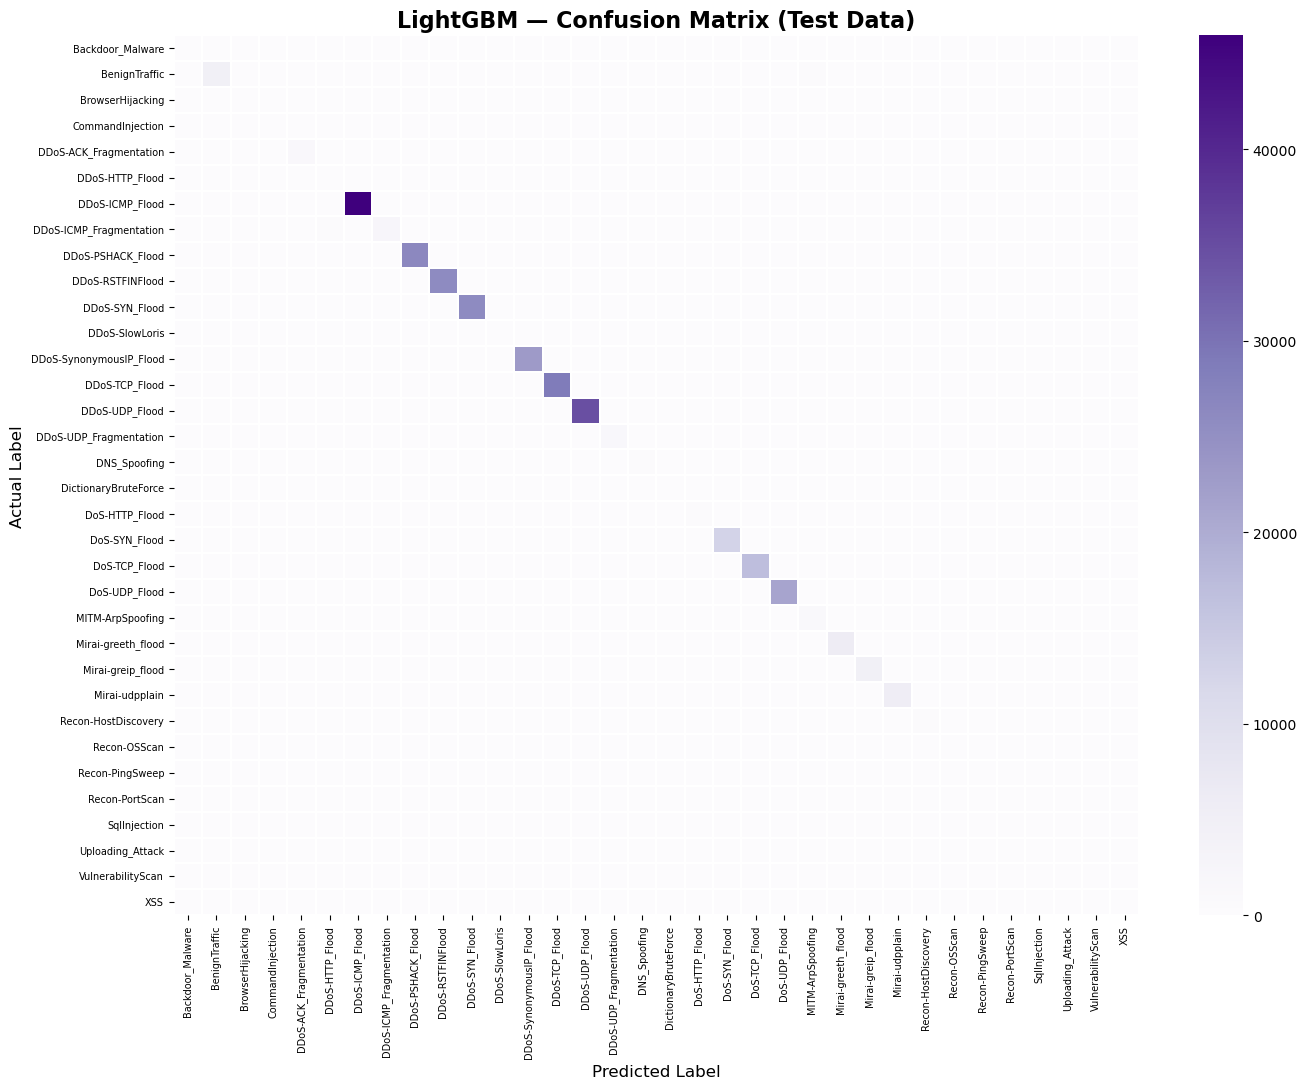


 Confusion matrix plotted successfully.
Note: Darker purple = higher true positive count (diagonal = correct predictions).


In [55]:

#CONFUSION MATRIX VISUALIZATION

print("=== Confusion Matrix Visualization ===")

cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(14, 11))
sns.heatmap(
    cm,
    annot=False,
    cmap='Purples',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    linewidths=0.3,
    linecolor='white'
)
plt.title('LightGBM — Confusion Matrix (Test Data)', fontsize=16, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

print("\n Confusion matrix plotted successfully.")
print("Note: Darker purple = higher true positive count (diagonal = correct predictions).")

=== Per-Class Accuracy Analysis ===

This shows which attack types the model handles well vs. struggles with.

Attack Type                           Accuracy    Support
------------------------------------------------------------
wrong Backdoor_Malware                      0.00%         25
wrong BrowserHijacking                      0.00%         34
wrong CommandInjection                      0.00%         31
wrong Uploading_Attack                      0.00%         12
wrong SqlInjection                          0.00%         31
wrong XSS                                   0.00%         22
wrong DictionaryBruteForce                  9.41%         85
wrong Recon-PingSweep                      10.00%         10
wrong Recon-OSScan                         17.76%        625
wrong Recon-PortScan                       23.78%        513
wrong DNS_Spoofing                         43.45%      1,183
warning Recon-HostDiscovery                  57.00%        879
warning DDoS-SlowLoris              

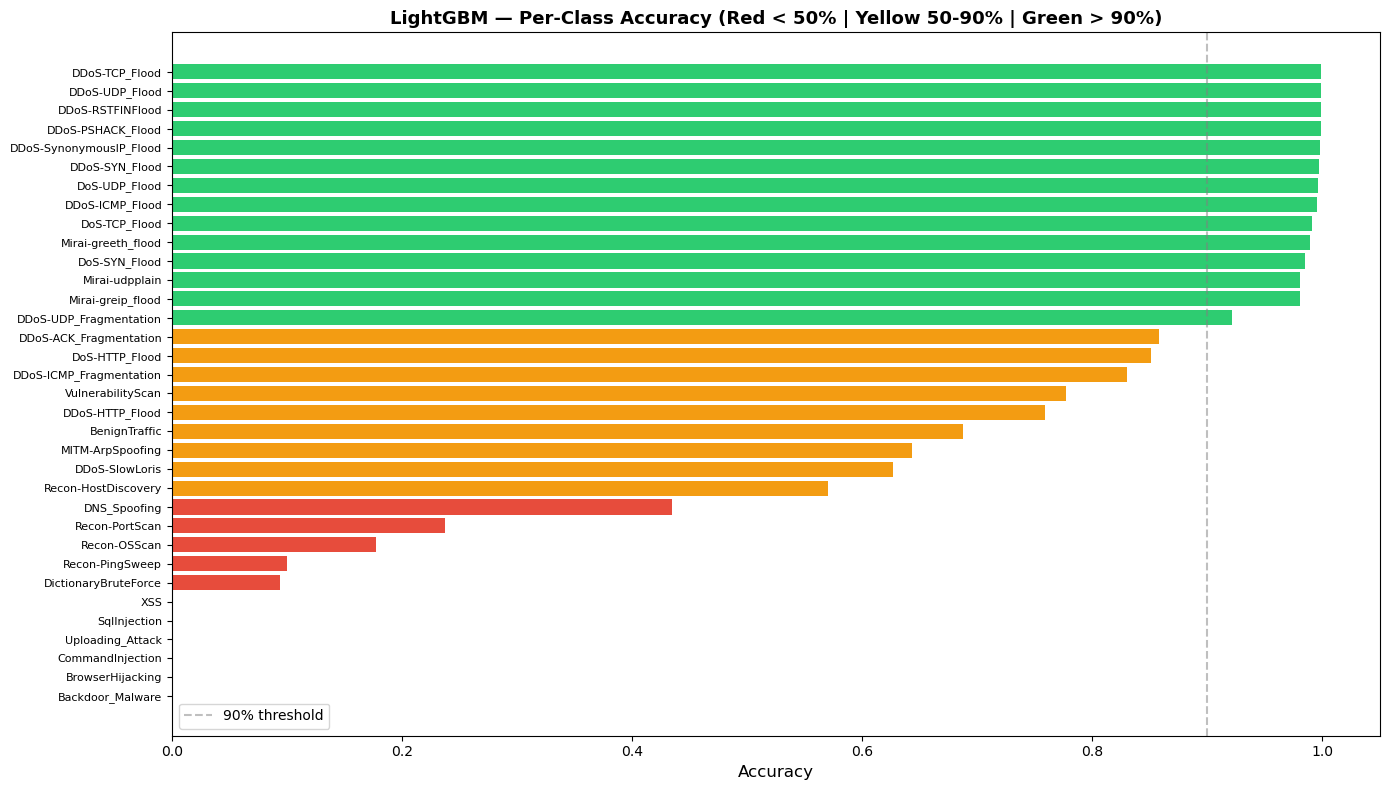


 Summary: 14/34 classes achieve >90% accuracy
   Classes below 50%: ['Backdoor_Malware', 'BrowserHijacking', 'CommandInjection', 'Uploading_Attack', 'SqlInjection', 'XSS', 'DictionaryBruteForce', 'Recon-PingSweep', 'Recon-OSScan', 'Recon-PortScan', 'DNS_Spoofing']


In [56]:

# PER-CLASS ACCURACY ANALYSIS

print("=== Per-Class Accuracy Analysis ===")
print("\nThis shows which attack types the model handles well vs. struggles with.\n")

per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
class_names_in_test = label_encoder.classes_

accuracy_df = pd.DataFrame({
    'Attack_Type': class_names_in_test[:len(per_class_accuracy)],
    'Accuracy': per_class_accuracy,
    'Support': cm.sum(axis=1)
}).sort_values('Accuracy', ascending=True)

print(f"{'Attack Type':35s} {'Accuracy':>10s} {'Support':>10s}")
print("-" * 60)
for _, row in accuracy_df.iterrows():
    status = 'correct' if row['Accuracy'] >= 0.90 else ('warning' if row['Accuracy'] >= 0.50 else 'wrong')
    print(f"{status} {row['Attack_Type']:33s} {row['Accuracy']:>9.2%} {int(row['Support']):>10,}")

plt.figure(figsize=(14, 8))
colors = ['#e74c3c' if acc < 0.5 else '#f39c12' if acc < 0.9 else '#2ecc71'
          for acc in accuracy_df['Accuracy']]
plt.barh(range(len(accuracy_df)), accuracy_df['Accuracy'], color=colors)
plt.yticks(range(len(accuracy_df)), accuracy_df['Attack_Type'], fontsize=8)
plt.xlabel('Accuracy', fontsize=12)
plt.title('LightGBM — Per-Class Accuracy (Red < 50% | Yellow 50-90% | Green > 90%)', fontsize=13, fontweight='bold')
plt.axvline(x=0.9, color='gray', linestyle='--', alpha=0.5, label='90% threshold')
plt.xlim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n Summary: {(per_class_accuracy >= 0.9).sum()}/{len(per_class_accuracy)} classes achieve >90% accuracy")
print(f"   Classes below 50%: {list(accuracy_df[accuracy_df['Accuracy'] < 0.5]['Attack_Type'].values)}")

=== Feature Importance Analysis ===


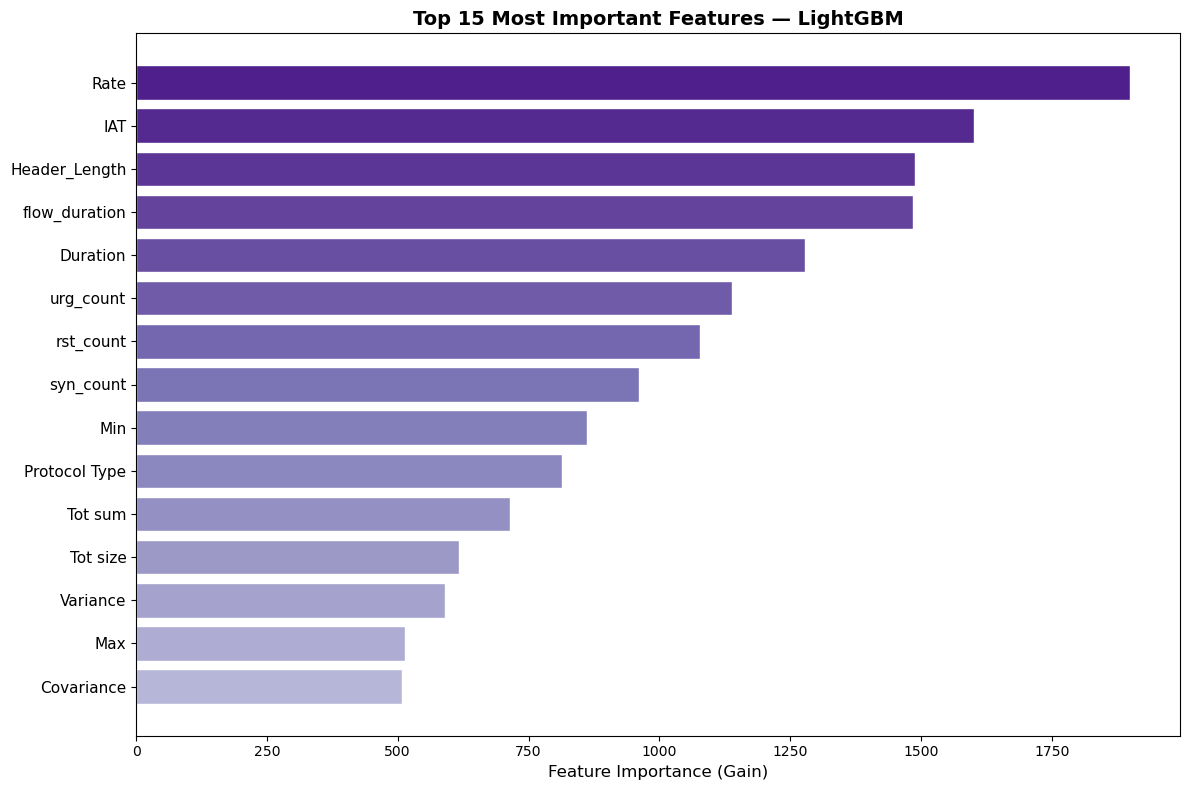


--- Top 15 Features by Gain ---
   1. Rate                       Importance:     1900.0
   2. IAT                        Importance:     1601.0
   3. Header_Length              Importance:     1488.0
   4. flow_duration              Importance:     1484.0
   5. Duration                   Importance:     1278.0
   6. urg_count                  Importance:     1138.0
   7. rst_count                  Importance:     1078.0
   8. syn_count                  Importance:      961.0
   9. Min                        Importance:      861.0
  10. Protocol Type              Importance:      813.0
  11. Tot sum                    Importance:      715.0
  12. Tot size                   Importance:      617.0
  13. Variance                   Importance:      590.0
  14. Max                        Importance:      513.0
  15. Covariance                 Importance:      509.0

 Note: 'Gain' measures how much each feature contributes to reducing
   the loss function across all trees. Higher gain = more

In [57]:

#FEATURE IMPORTANCE ANALYSIS

print("=== Feature Importance Analysis ===")


feature_names = X_train.columns
importances_gain = lgb_model.feature_importances_

top_n = 15
indices = np.argsort(importances_gain)[-top_n:]
plt.figure(figsize=(12, 8))
colors = plt.cm.Purples(np.linspace(0.4, 0.9, top_n))
plt.barh(range(top_n), importances_gain[indices], color=colors, edgecolor='white')
plt.yticks(range(top_n), [feature_names[i] for i in indices], fontsize=11)
plt.xlabel('Feature Importance (Gain)', fontsize=12)
plt.title(f'Top {top_n} Most Important Features — LightGBM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n--- Top {top_n} Features by Gain ---")
for rank, idx in enumerate(reversed(indices), 1):
    print(f"  {rank:2d}. {feature_names[idx]:25s}  Importance: {importances_gain[idx]:>10.1f}")

print("\n Note: 'Gain' measures how much each feature contributes to reducing")
print("   the loss function across all trees. Higher gain = more impactful feature.")

In [58]:

# TARGET LABEL ENCODING MAPPING

print("=== Target Label Mapping (Number → Attack Name) ===\n")


for index, attack_name in enumerate(label_encoder.classes_):
    print(f"  Number {index:2d}  →  {attack_name}")

=== Target Label Mapping (Number → Attack Name) ===

  Number  0  →  Backdoor_Malware
  Number  1  →  BenignTraffic
  Number  2  →  BrowserHijacking
  Number  3  →  CommandInjection
  Number  4  →  DDoS-ACK_Fragmentation
  Number  5  →  DDoS-HTTP_Flood
  Number  6  →  DDoS-ICMP_Flood
  Number  7  →  DDoS-ICMP_Fragmentation
  Number  8  →  DDoS-PSHACK_Flood
  Number  9  →  DDoS-RSTFINFlood
  Number 10  →  DDoS-SYN_Flood
  Number 11  →  DDoS-SlowLoris
  Number 12  →  DDoS-SynonymousIP_Flood
  Number 13  →  DDoS-TCP_Flood
  Number 14  →  DDoS-UDP_Flood
  Number 15  →  DDoS-UDP_Fragmentation
  Number 16  →  DNS_Spoofing
  Number 17  →  DictionaryBruteForce
  Number 18  →  DoS-HTTP_Flood
  Number 19  →  DoS-SYN_Flood
  Number 20  →  DoS-TCP_Flood
  Number 21  →  DoS-UDP_Flood
  Number 22  →  MITM-ArpSpoofing
  Number 23  →  Mirai-greeth_flood
  Number 24  →  Mirai-greip_flood
  Number 25  →  Mirai-udpplain
  Number 26  →  Recon-HostDiscovery
  Number 27  →  Recon-OSScan
  Number 28  →  Reco

=== Training vs Validation Learning Curve ===


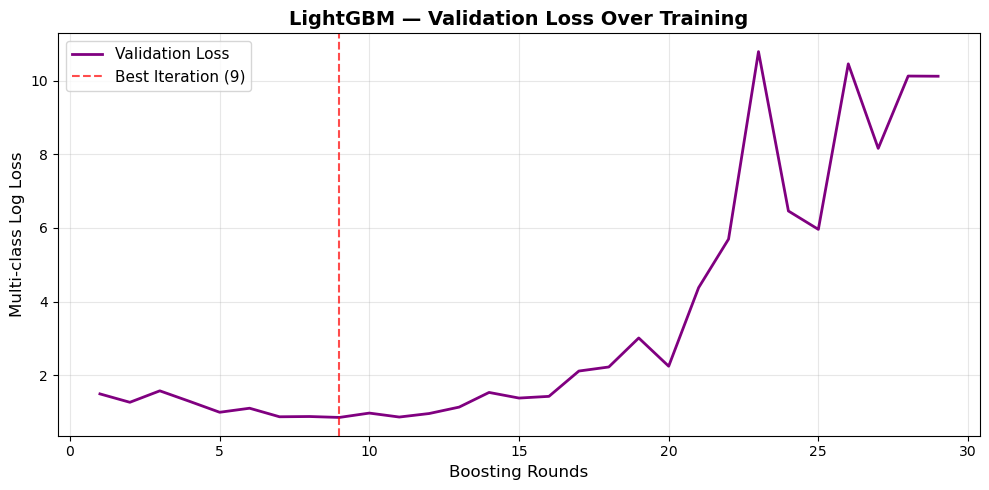


Final Validation Loss: 10.117268
Best Validation Loss:  0.856603 (at iteration 9)


In [59]:

# LEARNING CURVE VISUALIZATION

print("=== Training vs Validation Learning Curve ===")

results = lgb_model.evals_result_

if 'validation' in results:
    val_loss = results['validation']['multi_logloss']
    epochs = range(1, len(val_loss) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, val_loss, 'purple', linewidth=2, label='Validation Loss')

    best_iter = lgb_model.best_iteration_
    if best_iter and best_iter <= len(val_loss):
        plt.axvline(x=best_iter, color='red', linestyle='--', alpha=0.7,
                    label=f'Best Iteration ({best_iter})')

    plt.xlabel('Boosting Rounds', fontsize=12)
    plt.ylabel('Multi-class Log Loss', fontsize=12)
    plt.title('LightGBM — Validation Loss Over Training', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nFinal Validation Loss: {val_loss[-1]:.6f}")
    print(f"Best Validation Loss:  {min(val_loss):.6f} (at iteration {best_iter})")
else:
    print("No validation history available to plot.")

In [60]:

# MODEL SUMMARY AND COMPARISON TABLE

print("=" * 60)
print("       FINAL MODEL SUMMARY — LightGBM")
print("=" * 60)

print(f"""
  Algorithm         : LightGBM (Light Gradient Boosting Machine)
  Framework         : Microsoft LightGBM
  Tree Growth       : Leaf-wise (best-first)
  Split Strategy    : Histogram-based binning
  Boosting Type     : GBDT (Gradient Boosting Decision Tree)

  Hyperparameters:
    n_estimators    : 200 (with early stopping at {lgb_model.best_iteration_})
    learning_rate   : 0.1
    num_leaves      : 63
    max_depth       : -1 (unlimited)
    subsample       : 0.8
    colsample_bytree: 0.8
    is_unbalance    : True
    random_state    : 42

  Results on Test Set ({len(y_test_encoded):,} samples):
    Accuracy         : {accuracy:.4f} ({accuracy*100:.2f}%)
    F1-Score (Wt.)   : {f1_weighted:.4f} ({f1_weighted*100:.2f}%)
    F1-Score (Macro) : {f1_macro:.4f} ({f1_macro*100:.2f}%)
    Precision (Wt.)  : {precision:.4f} ({precision*100:.2f}%)
    Recall (Wt.)     : {recall:.4f} ({recall*100:.2f}%)
    Training Time    : {training_time:.2f} seconds
""")

print("--- Comparison with Team Models ---")
print(f"{'Model':20s} {'Accuracy':>10s} {'F1 (Weighted)':>14s}")
print("-" * 48)
print(f"{'XGBoost':20s} {'99.39%':>10s} {'99.33%':>14s}")
print(f"{'Random Forest':20s} {'99.34%':>10s} {'99.29%':>14s}")
print(f"{'LightGBM (Ours)':20s} {accuracy*100:>9.2f}% {f1_weighted*100:>13.2f}%")
print("-" * 48)

       FINAL MODEL SUMMARY — LightGBM

  Algorithm         : LightGBM (Light Gradient Boosting Machine)
  Framework         : Microsoft LightGBM
  Tree Growth       : Leaf-wise (best-first)
  Split Strategy    : Histogram-based binning
  Boosting Type     : GBDT (Gradient Boosting Decision Tree)

  Hyperparameters:
    n_estimators    : 200 (with early stopping at 9)
    learning_rate   : 0.1
    num_leaves      : 63
    max_depth       : -1 (unlimited)
    subsample       : 0.8
    colsample_bytree: 0.8
    is_unbalance    : True
    random_state    : 42

  Results on Test Set (300,000 samples):
    Accuracy         : 0.9752 (97.52%)
    F1-Score (Wt.)   : 0.9778 (97.78%)
    F1-Score (Macro) : 0.6033 (60.33%)
    Precision (Wt.)  : 0.9812 (98.12%)
    Recall (Wt.)     : 0.9752 (97.52%)
    Training Time    : 33.86 seconds

--- Comparison with Team Models ---
Model                  Accuracy  F1 (Weighted)
------------------------------------------------
XGBoost                  99.39%

In [61]:

#  REAL-TIME INTRUSION DETECTION DEMO

print("Real-time Intrusion Detection Demo ")
print("   Using LightGBM to classify a single network packet\n")

random_index = random.randint(0, len(X_test) - 1)
sample_packet = X_test.iloc[[random_index]]

actual_label_encoded = y_test_encoded[random_index]
actual_label_text = label_encoder.inverse_transform([actual_label_encoded])[0]

print(f"Selected Packet Index: {random_index}")
print(f"ACTUAL Traffic Type (Hidden from Model): {actual_label_text}")
print()

sample_packet_scaled = scaler.transform(sample_packet)

print("  Analyzing network packet through LightGBM model...")
predicted_label_encoded = lgb_model.predict(sample_packet_scaled)
predicted_label_text = label_encoder.inverse_transform(predicted_label_encoded)[0]

print()
print("  " + "-" * 50)
print(f"MODEL PREDICTION: {predicted_label_text}")
print("  " + "-" * 50)

if actual_label_text == predicted_label_text:
    print(f"\n  SUCCESS: The model correctly identified the network traffic!")
    print(f"     Both actual and predicted: '{actual_label_text}'")
else:
    print(f"\n  MISMATCH: The model misclassified the network traffic.")
    print(f"     Actual: '{actual_label_text}' | Predicted: '{predicted_label_text}'")

Real-time Intrusion Detection Demo 
   Using LightGBM to classify a single network packet

Selected Packet Index: 10546
ACTUAL Traffic Type (Hidden from Model): DDoS-SYN_Flood

  Analyzing network packet through LightGBM model...

  --------------------------------------------------
MODEL PREDICTION: DDoS-SYN_Flood
  --------------------------------------------------

  SUCCESS: The model correctly identified the network traffic!
     Both actual and predicted: 'DDoS-SYN_Flood'


In [62]:

# MANUAL PACKET INSPECTION AND VERIFICATION

print("=== Cross-Checking Model vs Actual Dataset ===\n")

row_number = 550

my_packet = X_test.iloc[[row_number]]
actual_label = y_test.iloc[row_number]

print("--- 1. Original Dataset Details ---")
print(f"  Selected Row Index : {row_number}")
print(f"  Actual Attack Type : ** {actual_label} **")
print(f"  Flow Duration      : {my_packet['flow_duration'].values[0]}")
print(f"  Header Length      : {my_packet['Header_Length'].values[0]}")
print(f"  Protocol Type      : {my_packet['Protocol Type'].values[0]}")
print(f"  Rate               : {my_packet['Rate'].values[0]:.4f}")
print()

print("--- 2. LightGBM Model Prediction ---")
my_packet_scaled = scaler.transform(my_packet)
predicted_encoded = lgb_model.predict(my_packet_scaled)
predicted_label = label_encoder.inverse_transform(predicted_encoded)[0]
print(f"  Model Prediction   : ** {predicted_label} **")
print()

print("--- 3. Verification Result ---")
if actual_label == predicted_label:
    print(f" SUCCESS: Dataset label '{actual_label}' matches model prediction!")
    print(f"     The LightGBM model correctly identified this network packet.")
else:
    print(f" MISMATCH: Dataset has '{actual_label}', but model predicted '{predicted_label}'.")

=== Cross-Checking Model vs Actual Dataset ===

--- 1. Original Dataset Details ---
  Selected Row Index : 550
  Actual Attack Type : ** DDoS-SynonymousIP_Flood **
  Flow Duration      : 0.1311020565032959
  Header Length      : 75.6
  Protocol Type      : 6.0
  Rate               : 6.1308

--- 2. LightGBM Model Prediction ---
  Model Prediction   : ** DDoS-SynonymousIP_Flood **

--- 3. Verification Result ---
 SUCCESS: Dataset label 'DDoS-SynonymousIP_Flood' matches model prediction!
     The LightGBM model correctly identified this network packet.


In [63]:

#  BATCH PREDICTION DEMO

print("=== Batch Prediction Demo (10 Random Samples) ===\n")

# Select 10 random samples for demonstration
random_indices = random.sample(range(len(X_test)), 10)
correct = 0

print(f"{'#':>3s} {'Index':>7s} {'Actual':>30s} {'Predicted':>30s} {'Result':>8s}")
print("-" * 85)

for i, idx in enumerate(random_indices, 1):
    sample = X_test.iloc[[idx]]
    sample_scaled = scaler.transform(sample)

    actual = label_encoder.inverse_transform([y_test_encoded[idx]])[0]
    predicted = label_encoder.inverse_transform(lgb_model.predict(sample_scaled))[0]

    match = 'correct' if actual == predicted else 'wrong'
    if actual == predicted:
        correct += 1

    print(f"{i:3d} {idx:7d} {actual:>30s} {predicted:>30s} {match:>8s}")

print("-" * 85)
print(f"\n Batch Result: {correct}/10 correct ({correct*10}% accuracy on this sample)")

=== Batch Prediction Demo (10 Random Samples) ===

  #   Index                         Actual                      Predicted   Result
-------------------------------------------------------------------------------------
  1   32489                  DoS-UDP_Flood                  DoS-UDP_Flood  correct
  2   83018                   DNS_Spoofing                   DNS_Spoofing  correct
  3   13352        DDoS-SynonymousIP_Flood        DDoS-SynonymousIP_Flood  correct
  4    4087                DDoS-ICMP_Flood                DDoS-ICMP_Flood  correct
  5  273534                DDoS-ICMP_Flood                DDoS-ICMP_Flood  correct
  6  289210                 DDoS-SYN_Flood                 DDoS-SYN_Flood  correct
  7  297834                  BenignTraffic                  BenignTraffic  correct
  8   14212        DDoS-SynonymousIP_Flood        DDoS-SynonymousIP_Flood  correct
  9   16353               MITM-ArpSpoofing                   DNS_Spoofing    wrong
 10  169256                  Beni